In [ ]:
!pip install pandas numpy matplotlib seaborn plotly ydata-profiling scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.7 MB/s eta 0:00:00


In [ ]:
import os
#1 Crear las carpetas de salida
os.makedirs("solaris/output", exist_ok=True)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from ydata_profiling import ProfileReport
from scipy import stats


/tmp/ipykernel_630/3189681568.py:6: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df = pd.read_csv('/content/drive/MyDrive/PROYECTO EN CIENCIA DE DATOS 2/SOLARIS_FrescaMar_cartera_credito.csv')
df

,id_cliente,edad,ingreso_mensual,nivel_educativo,ciudad,fecha_vinculacion,saldo_actual,cuotas_pagadas,cuotas_totales,estado_cuenta,score_externo
0,CLI-100000,71,11525805,Posgrado,Cali,2021-04-07,4484274,26,48,Al día,790.0
1,CLI-100001,25,0,Tecnólogo,SANTA MARTA,2015-04-02,476422,32,36,Al día,747.0
2,CLI-100002,34,2186293,Secundaria,SANTA MARTA,2020-11-25,362454,3,6,Al día,367.0
3,CLI-100003,73,0,Tecnólogo,ibague,2016-11-23,2225927,28,48,Al día,533.0
4,CLI-100004,45,0,Universitario,CARTAGENA,2023-06-18,8870010,19,48,Al día,685.0
...,...,...,...,...,...,...,...,...,...,...,...
14995,CLI-114995,21,6348411,Universitario,Medellin,2020-02-21,23226872,13,48,Moroso,808.0
14996,CLI-114996,26,4687892,Universitario,CÚCUTA,2017-06-11,446575,10,12,Al día,509.0
14997,CLI-114997,51,0,Universitario,bogota,2021-11-06,3614378,11,24,Al día,483.0
14998,CLI-114998,29,1155799,Secundaria,SANTA MARTA,2019-06-24,0,18,18,Cancelado,449.0


In [7]:
filas, columnas = df.shape

print(f"Número de filas: {filas:,}")
print(f"Número de columnas: {columnas}")
print(f"Dimensiones completas: {df.shape}")

Número de filas: 15,000
Número de columnas: 11
Dimensiones completas: (15000, 11)


In [8]:
df.dtypes.value_counts()

,count
object,5
int64,5
float64,1


In [9]:
df.dtypes

,0
id_cliente,object
edad,int64
ingreso_mensual,int64
nivel_educativo,object
ciudad,object
fecha_vinculacion,object
saldo_actual,int64
cuotas_pagadas,int64
cuotas_totales,int64
estado_cuenta,object


In [10]:
tipos_columnas = pd.DataFrame({
    'columna': df.columns,
    'tipo_detectado': df.dtypes.astype(str).values
})

tipos_columnas

,columna,tipo_detectado
0,id_cliente,object
1,edad,int64
2,ingreso_mensual,int64
3,nivel_educativo,object
4,ciudad,object
5,fecha_vinculacion,object
6,saldo_actual,int64
7,cuotas_pagadas,int64
8,cuotas_totales,int64
9,estado_cuenta,object


In [11]:
memoria_bytes = df.memory_usage(deep=True).sum()
memoria_mb = memoria_bytes / (1024 ** 2)

print(f"Memoria utilizada: {memoria_bytes:,} bytes")
print(f"Memoria utilizada: {memoria_mb:.2f} MB")

Memoria utilizada: 5,572,427 bytes
Memoria utilizada: 5.31 MB


In [12]:
df.head()

,id_cliente,edad,ingreso_mensual,nivel_educativo,ciudad,fecha_vinculacion,saldo_actual,cuotas_pagadas,cuotas_totales,estado_cuenta,score_externo
0,CLI-100000,71,11525805,Posgrado,Cali,2021-04-07,4484274,26,48,Al día,790.0
1,CLI-100001,25,0,Tecnólogo,SANTA MARTA,2015-04-02,476422,32,36,Al día,747.0
2,CLI-100002,34,2186293,Secundaria,SANTA MARTA,2020-11-25,362454,3,6,Al día,367.0
3,CLI-100003,73,0,Tecnólogo,ibague,2016-11-23,2225927,28,48,Al día,533.0
4,CLI-100004,45,0,Universitario,CARTAGENA,2023-06-18,8870010,19,48,Al día,685.0


In [13]:
#2 Configurar el informe
perfil=ProfileReport(df, explorative=True, minimal=False)
perfil.to_file("solaris/output/Perfil_Final.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 28.00it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
import matplotlib.pyplot as plt

carpeta_salida = "solaris/output"
os.makedirs(carpeta_salida, exist_ok=True)

# PASO 3. Distribuciones univariadas de variables numéricas

In [15]:
columnas_numericas = df.select_dtypes(include=[np.number])

print(f"Cantidad de columnas numéricas: {columnas_numericas.shape[1]}")
print("Columnas numéricas encontradas:")

for columna in columnas_numericas.columns:
    print(f"- {columna}")

Cantidad de columnas numéricas: 6
Columnas numéricas encontradas:
- edad
- ingreso_mensual
- saldo_actual
- cuotas_pagadas
- cuotas_totales
- score_externo


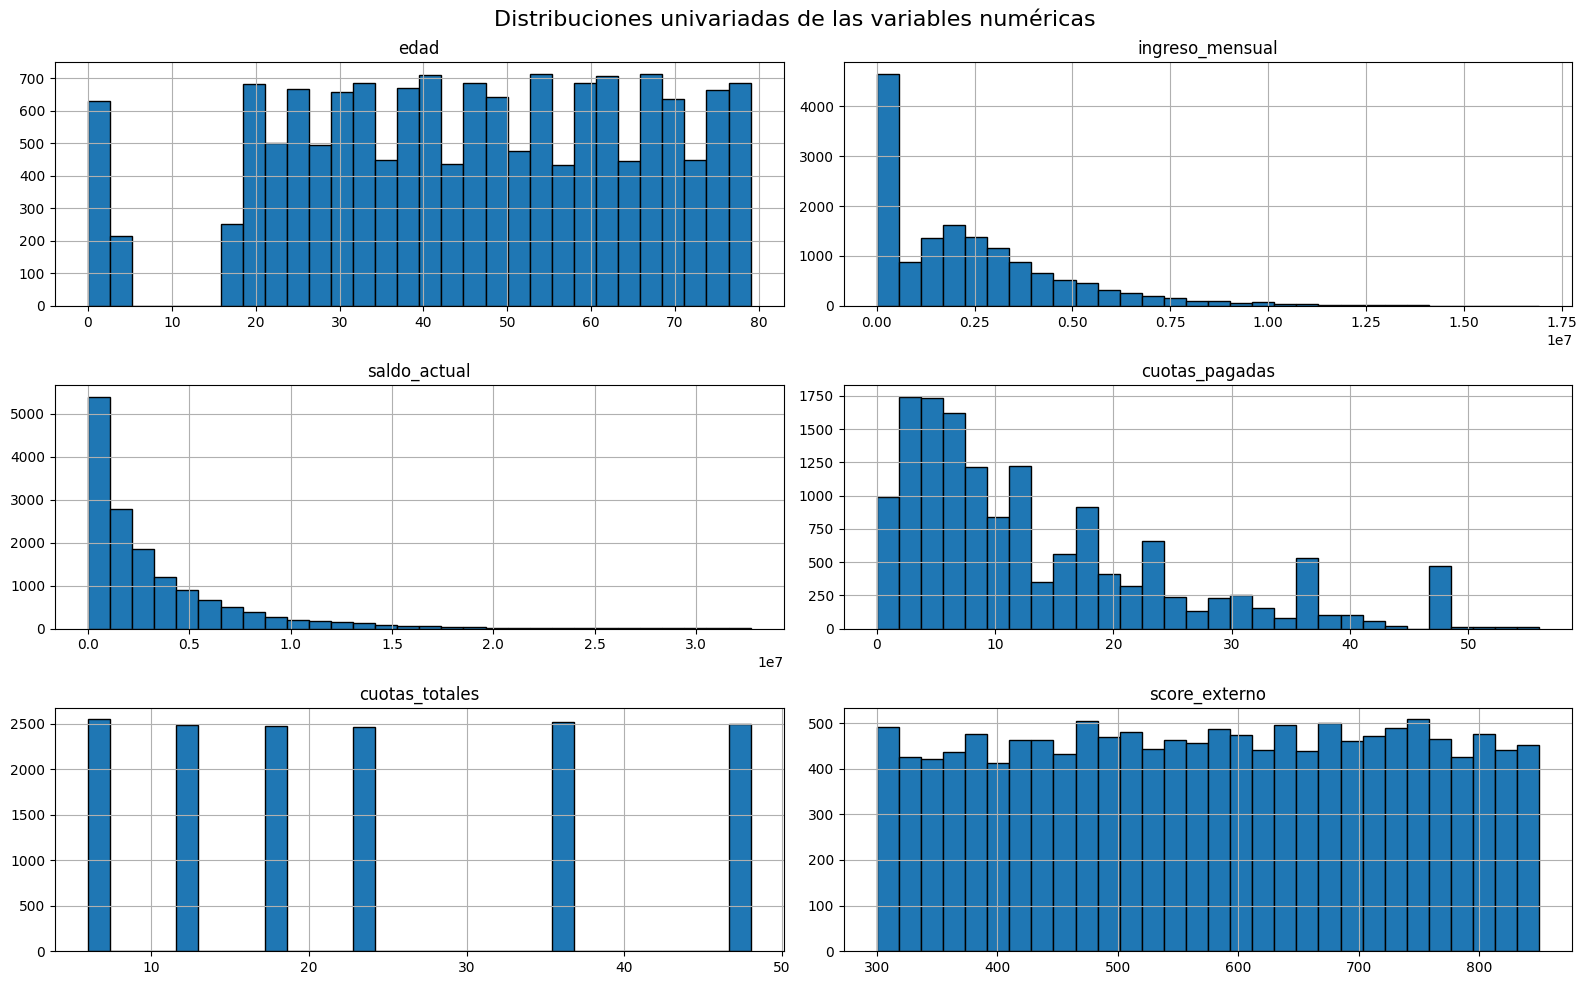

Imagen guardada en: solaris/output/distribuciones_univariadas.png


In [16]:
columnas_numericas = df.select_dtypes(include=[np.number])

columnas_numericas.hist(
    bins=30,
    figsize=(16, 10),
    edgecolor="black"
)

plt.suptitle(
    "Distribuciones univariadas de las variables numéricas",
    fontsize=16
)

plt.tight_layout()

ruta_histogramas = os.path.join(
    carpeta_salida,
    "distribuciones_univariadas.png"
)

plt.savefig(
    ruta_histogramas,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Imagen guardada en:", ruta_histogramas)

In [17]:
import os
import numpy as np
import pandas as pd

# Carpeta donde se guardó el informe anterior
carpeta_salida = "solaris/output"
os.makedirs(carpeta_salida, exist_ok=True)

# Seleccionar únicamente columnas numéricas
df_numericas = df.select_dtypes(include=[np.number])

alertas = []

for columna in df_numericas.columns:

    datos = df_numericas[columna].dropna()

    if datos.empty:
        continue

    # ---------------------------------------------------------
    # 1. Buscar distribución aproximadamente uniforme
    #    Posible identificador numérico disfrazado
    # ---------------------------------------------------------
    if datos.nunique() >= 20:

        frecuencias, _ = np.histogram(datos, bins=20)

        promedio_bins = frecuencias.mean()

        if promedio_bins > 0:
            coeficiente_variacion = frecuencias.std() / promedio_bins
        else:
            coeficiente_variacion = np.nan

        proporcion_unicos = datos.nunique() / len(datos)

        # Regla exploratoria:
        # - Más del 80 % de valores son únicos
        # - Las frecuencias de los bins son similares
        if (
            proporcion_unicos > 0.80
            and coeficiente_variacion < 0.20
        ):
            alertas.append({
                "columna": columna,
                "tipo_alerta": "Posible distribución uniforme",
                "detalle": (
                    f"{proporcion_unicos:.2%} de los valores son únicos "
                    f"y el coeficiente de variación entre bins es "
                    f"{coeficiente_variacion:.3f}. "
                    "Podría tratarse de un ID numérico disfrazado."
                )
            })

    # ---------------------------------------------------------
    # 2. Buscar un solo bin dominante superior al 95 %
    # ---------------------------------------------------------
    frecuencias, limites = np.histogram(datos, bins=30)

    posicion_dominante = np.argmax(frecuencias)
    proporcion_dominante = frecuencias[posicion_dominante] / len(datos)

    if proporcion_dominante > 0.95:

        limite_inferior = limites[posicion_dominante]
        limite_superior = limites[posicion_dominante + 1]

        alertas.append({
            "columna": columna,
            "tipo_alerta": "Un solo bin dominante",
            "detalle": (
                f"El {proporcion_dominante:.2%} de los registros se encuentra "
                f"entre {limite_inferior:.2f} y {limite_superior:.2f}. "
                "La variable podría ser casi constante o tener un valor "
                "utilizado como código."
            )
        })


# -------------------------------------------------------------
# 3. Buscar valores imposibles en la edad
# -------------------------------------------------------------
if "edad" in df.columns:

    edades_negativas = df["edad"] < 0
    edades_mayores_120 = df["edad"] > 120

    if edades_negativas.any():
        alertas.append({
            "columna": "edad",
            "tipo_alerta": "Edad negativa",
            "detalle": (
                f"Se encontraron {edades_negativas.sum()} registros "
                "con una edad inferior a cero."
            )
        })

    if edades_mayores_120.any():
        alertas.append({
            "columna": "edad",
            "tipo_alerta": "Edad superior a 120",
            "detalle": (
                f"Se encontraron {edades_mayores_120.sum()} registros "
                "con una edad superior a 120 años."
            )
        })


# -------------------------------------------------------------
# 4. Detectar columnas que posiblemente representan porcentajes
# -------------------------------------------------------------
palabras_porcentaje = [
    "porcentaje",
    "percent",
    "porc",
    "pct",
    "tasa"
]

columnas_porcentaje = [
    columna
    for columna in df_numericas.columns
    if any(
        palabra in columna.lower()
        for palabra in palabras_porcentaje
    )
]

for columna in columnas_porcentaje:

    valores_mayores_100 = df[columna] > 100
    valores_negativos = df[columna] < 0

    if valores_mayores_100.any():
        alertas.append({
            "columna": columna,
            "tipo_alerta": "Porcentaje superior a 100",
            "detalle": (
                f"Se encontraron {valores_mayores_100.sum()} registros "
                "con valores superiores a 100."
            )
        })

    if valores_negativos.any():
        alertas.append({
            "columna": columna,
            "tipo_alerta": "Porcentaje negativo",
            "detalle": (
                f"Se encontraron {valores_negativos.sum()} registros "
                "con valores inferiores a cero."
            )
        })


# -------------------------------------------------------------
# Crear y mostrar el informe de alertas
# -------------------------------------------------------------
alertas_df = pd.DataFrame(
    alertas,
    columns=["columna", "tipo_alerta", "detalle"]
)

if alertas_df.empty:
    print("No se encontraron alertas con las reglas establecidas.")
else:
    print(f"Se encontraron {len(alertas_df)} alertas:")
    display(alertas_df)

# Guardar resultados
ruta_alertas = os.path.join(
    carpeta_salida,
    "alertas_distribuciones.csv"
)

alertas_df.to_csv(
    ruta_alertas,
    index=False,
    encoding="utf-8-sig"
)

print(f"\nResultados guardados en: {ruta_alertas}")

No se encontraron alertas con las reglas establecidas.

Resultados guardados en: solaris/output/alertas_distribuciones.csv


In [18]:
if "edad" in df.columns:

    registros_edad_imposible = df[
        (df["edad"] < 0) |
        (df["edad"] > 120)
    ]

    print(
        f"Cantidad de registros con edades imposibles: "
        f"{len(registros_edad_imposible)}"
    )

    display(
        registros_edad_imposible[
            ["id_cliente", "edad", "fecha_vinculacion", "estado_cuenta"]
        ].head(20)
    )

Cantidad de registros con edades imposibles: 0


,id_cliente,edad,fecha_vinculacion,estado_cuenta


In [19]:
df["ciudad"].value_counts().head(60)

,count
ciudad,
MZL,283
"Manizales, Caldas",274
Villavo,274
PEREIRA,274
Ibagué,268
cucuta,265
PEI,262
pereira,260
"Pereira, Risaralda",258


#PASO 4.

In [20]:
correlacion_pearson = df_numericas.corr(method="pearson")
correlacion_spearman = df_numericas.corr(method="spearman")
correlacion_kendall = df_numericas.corr(method="kendall")

print("Matrices de correlación calculadas correctamente.")

display(correlacion_pearson)
display(correlacion_spearman)
display(correlacion_kendall)

Matrices de correlación calculadas correctamente.


,edad,ingreso_mensual,saldo_actual,cuotas_pagadas,cuotas_totales,score_externo
edad,1.000000,0.005666,-0.022669,0.036941,0.003907,0.001369
ingreso_mensual,0.005666,1.000000,-0.082238,0.068693,-0.012084,-0.009687
saldo_actual,-0.022669,-0.082238,1.000000,-0.160804,0.459640,0.006685
cuotas_pagadas,0.036941,0.068693,-0.160804,1.000000,0.702701,0.008960
cuotas_totales,0.003907,-0.012084,0.459640,0.702701,1.000000,0.005629
score_externo,0.001369,-0.009687,0.006685,0.008960,0.005629,1.000000


,edad,ingreso_mensual,saldo_actual,cuotas_pagadas,cuotas_totales,score_externo
edad,1.000000,0.007033,-0.025535,0.021114,0.003143,0.001975
ingreso_mensual,0.007033,1.000000,-0.178561,0.083774,-0.012912,-0.008272
saldo_actual,-0.025535,-0.178561,1.000000,-0.170505,0.421247,0.002682
cuotas_pagadas,0.021114,0.083774,-0.170505,1.000000,0.718035,0.001750
cuotas_totales,0.003143,-0.012912,0.421247,0.718035,1.000000,0.006260
score_externo,0.001975,-0.008272,0.002682,0.001750,0.006260,1.000000


,edad,ingreso_mensual,saldo_actual,cuotas_pagadas,cuotas_totales,score_externo
edad,1.000000,0.004872,-0.017304,0.014542,0.002314,0.001343
ingreso_mensual,0.004872,1.000000,-0.125219,0.059022,-0.009649,-0.005736
saldo_actual,-0.017304,-0.125219,1.000000,-0.118715,0.324285,0.001798
cuotas_pagadas,0.014542,0.059022,-0.118715,1.000000,0.575727,0.001218
cuotas_totales,0.002314,-0.009649,0.324285,0.575727,1.000000,0.004496
score_externo,0.001343,-0.005736,0.001798,0.001218,0.004496,1.000000


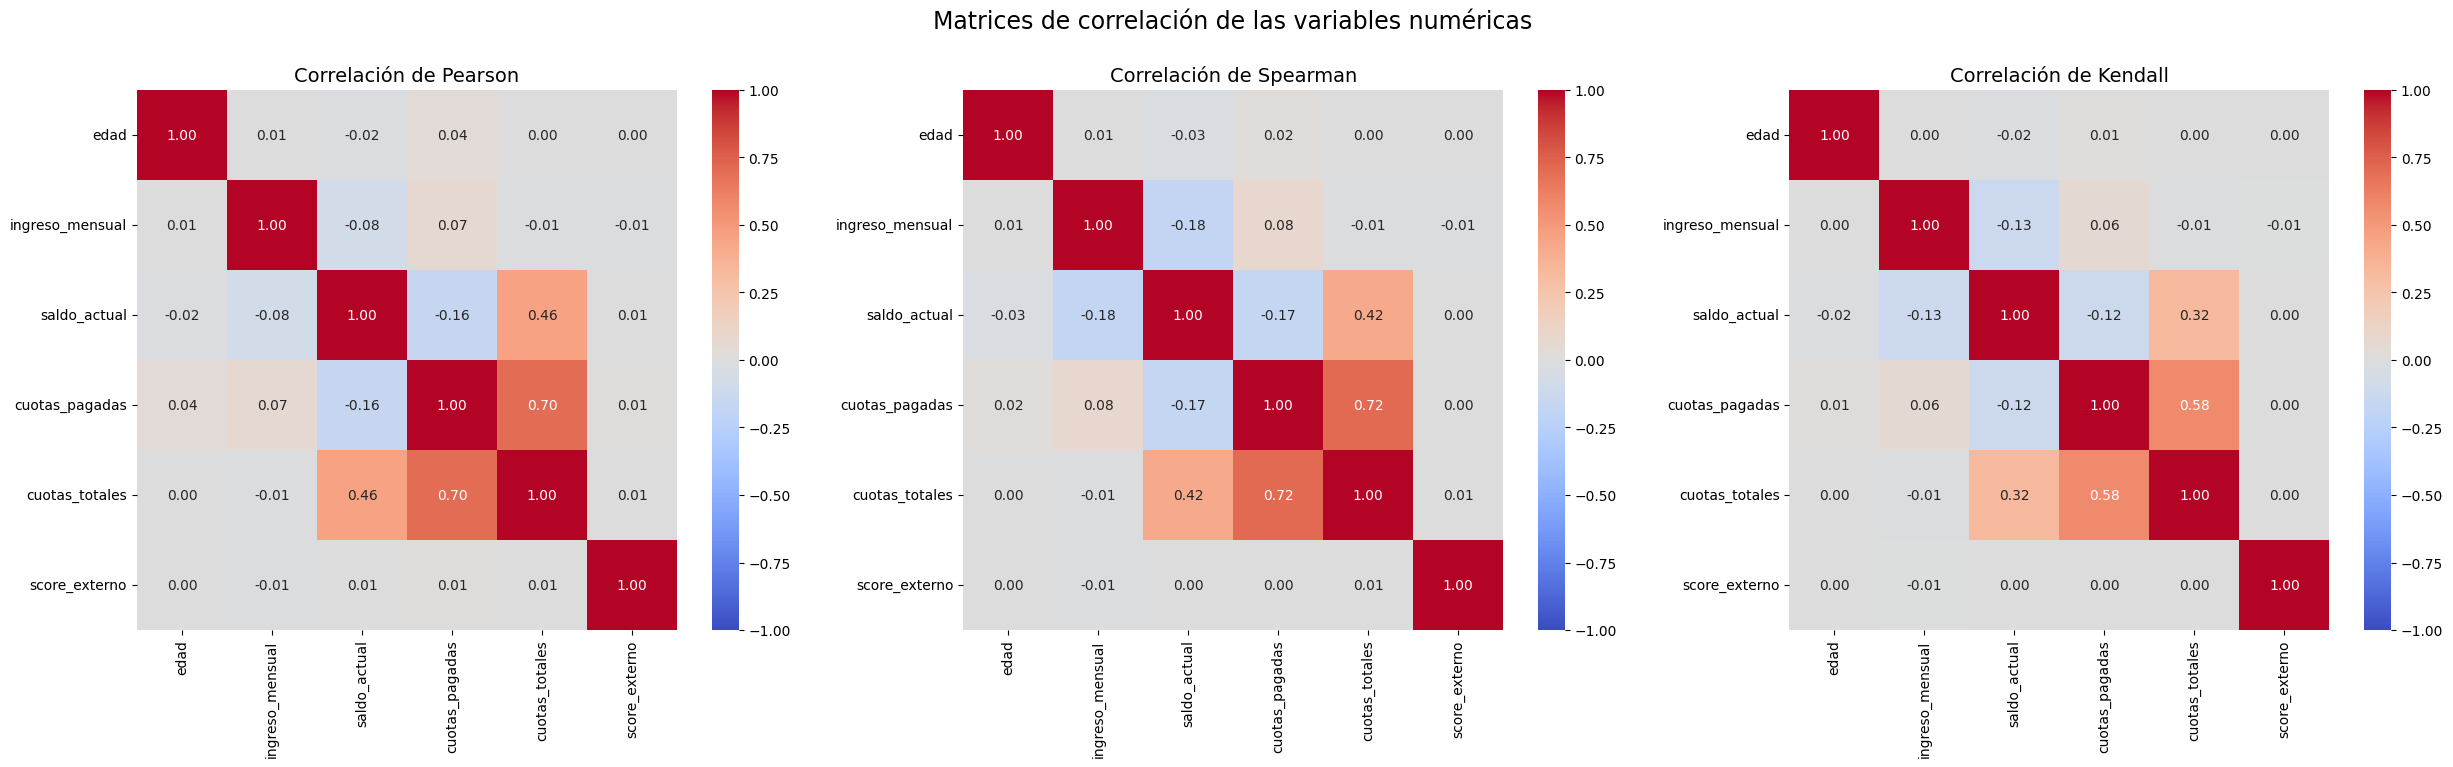

Imagen guardada correctamente en: solaris/output/correlaciones.png


In [21]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(25, 7)
)

sns.heatmap(
    correlacion_pearson,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[0]
)

axes[0].set_title("Correlación de Pearson", fontsize=14)

sns.heatmap(
    correlacion_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title("Correlación de Spearman", fontsize=14)

sns.heatmap(
    correlacion_kendall,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[2]
)

axes[2].set_title("Correlación de Kendall", fontsize=14)

plt.suptitle(
    "Matrices de correlación de las variables numéricas",
    fontsize=17,
    y=1.03
)

plt.tight_layout()

ruta_correlaciones = os.path.join(
    carpeta_salida,
    "correlaciones.png"
)

plt.savefig(
    ruta_correlaciones,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Imagen guardada correctamente en: {ruta_correlaciones}")

In [22]:
def obtener_correlaciones_altas(
    matriz_correlacion,
    metodo,
    umbral=0.85
):
    """
    Extrae pares de variables cuya correlación absoluta
    sea superior al umbral establecido.
    """

    mascara_superior = np.triu(
        np.ones(matriz_correlacion.shape, dtype=bool),
        k=1
    )

    correlaciones = (
        matriz_correlacion
        .where(mascara_superior)
        .stack()
        .reset_index()
    )

    correlaciones.columns = [
        "variable_1",
        "variable_2",
        "correlacion"
    ]

    correlaciones["correlacion_absoluta"] = (
        correlaciones["correlacion"].abs()
    )

    correlaciones["metodo"] = metodo

    correlaciones_altas = correlaciones[
        correlaciones["correlacion_absoluta"] > umbral
    ]

    return correlaciones_altas.sort_values(
        by="correlacion_absoluta",
        ascending=False
    )

altas_pearson = obtener_correlaciones_altas(
    correlacion_pearson,
    metodo="Pearson",
    umbral=0.85
)

altas_spearman = obtener_correlaciones_altas(
    correlacion_spearman,
    metodo="Spearman",
    umbral=0.85
)

altas_kendall = obtener_correlaciones_altas(
    correlacion_kendall,
    metodo="Kendall",
    umbral=0.85
)

correlaciones_altas = pd.concat(
    [
        altas_pearson,
        altas_spearman,
        altas_kendall
    ],
    ignore_index=True
)

if correlaciones_altas.empty:
    print(
        "No se encontraron pares con correlación "
        "absoluta superior a 0.85."
    )
else:
    print(
        f"Se encontraron {len(correlaciones_altas)} "
        "correlaciones superiores a 0.85:"
    )

    display(correlaciones_altas)

No se encontraron pares con correlación absoluta superior a 0.85.


#PASO 5. Detección de outliers con IQR y Z-score

In [23]:
import os
import numpy as np
import pandas as pd

numericas = df.select_dtypes(include=[np.number])
resultados = []
resumen = []

for columna in numericas.columns:
    datos = df[columna]
    datos_validos = datos.dropna()

    # IQR
    q1 = datos_validos.quantile(0.25)
    q3 = datos_validos.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_iqr = (
        (datos < limite_inferior) |
        (datos > limite_superior)
    )

    # Z-score
    media = datos_validos.mean()
    desviacion = datos_validos.std(ddof=0)

    if desviacion == 0:
        z_score = pd.Series(0, index=df.index)
    else:
        z_score = (datos - media) / desviacion

    mascara_z = z_score.abs() > 3

    # Asimetría
    asimetria = datos_validos.skew()
    metodo_recomendado = "IQR" if abs(asimetria) > 2 else "Ambos métodos"

    # Registros detectados por al menos un método
    mascara_outlier = mascara_iqr | mascara_z

    for indice in df.index[mascara_outlier]:
        valor = df.loc[indice, columna]
        detectado_iqr = bool(mascara_iqr.loc[indice])
        detectado_z = bool(mascara_z.loc[indice])

        nombre = columna.lower()

        if nombre == "edad" and (valor < 0 or valor > 120):
            hipotesis = "Probable error: edad fuera de un rango válido."
        elif any(p in nombre for p in ["porcentaje", "porc", "pct"]) and (
            valor < 0 or valor > 100
        ):
            hipotesis = "Probable error: porcentaje fuera del rango 0-100."
        elif detectado_iqr and detectado_z:
            hipotesis = "Valor extremo severo; validar con la fuente original."
        elif abs(asimetria) > 2 and detectado_iqr:
            hipotesis = (
                "Posible valor extremo real debido a la distribución asimétrica; "
                "validar antes de eliminar."
            )
        else:
            hipotesis = (
                "Posible valor extremo; revisar con reglas de negocio."
            )

        resultados.append({
            "indice": indice,
            "id_cliente": (
                df.loc[indice, "id_cliente"]
                if "id_cliente" in df.columns
                else np.nan
            ),
            "variable": columna,
            "valor": valor,
            "outlier_IQR": detectado_iqr,
            "outlier_Zscore": detectado_z,
            "z_score": z_score.loc[indice],
            "limite_inferior_IQR": limite_inferior,
            "limite_superior_IQR": limite_superior,
            "skewness": asimetria,
            "metodo_recomendado": metodo_recomendado,
            "hipotesis": hipotesis
        })

    resumen.append({
        "variable": columna,
        "skewness": asimetria,
        "outliers_IQR": int(mascara_iqr.sum()),
        "outliers_Zscore": int(mascara_z.sum()),
        "outliers_totales": int(mascara_outlier.sum()),
        "metodo_recomendado": metodo_recomendado
    })

reporte_outliers = pd.DataFrame(resultados)
resumen_outliers = pd.DataFrame(resumen)

reporte_outliers.to_csv(
    os.path.join(carpeta_salida, "reporte_outliers.csv"),
    index=False,
    encoding="utf-8-sig"
)

display(resumen_outliers)
display(reporte_outliers.head(20))

print(f"Total de registros documentados: {len(reporte_outliers)}")
print("Archivo guardado: reporte_outliers.csv")

,variable,skewness,outliers_IQR,outliers_Zscore,outliers_totales,metodo_recomendado
0,edad,-0.281646,0,0,0,Ambos métodos
1,ingreso_mensual,1.366965,353,238,353,Ambos métodos
2,saldo_actual,2.323555,1018,306,1018,IQR
3,cuotas_pagadas,1.241219,586,34,586,Ambos métodos
4,cuotas_totales,0.441893,0,0,0,Ambos métodos
5,score_externo,-0.021761,0,0,0,Ambos métodos


,indice,id_cliente,variable,valor,outlier_IQR,outlier_Zscore,z_score,limite_inferior_IQR,limite_superior_IQR,skewness,metodo_recomendado,hipotesis
0,0,CLI-100000,ingreso_mensual,11525805,True,True,3.810666,-5221229.625,8702049.375,1.366965,Ambos métodos,Valor extremo severo; validar con la fuente or...
1,30,CLI-100030,ingreso_mensual,9568213,True,False,2.999064,-5221229.625,8702049.375,1.366965,Ambos métodos,Posible valor extremo; revisar con reglas de n...
2,97,CLI-100097,ingreso_mensual,12051997,True,True,4.028821,-5221229.625,8702049.375,1.366965,Ambos métodos,Valor extremo severo; validar con la fuente or...
3,101,CLI-100101,ingreso_mensual,9406922,True,False,2.932194,-5221229.625,8702049.375,1.366965,Ambos métodos,Posible valor extremo; revisar con reglas de n...
4,104,CLI-100104,ingreso_mensual,10644038,True,True,3.445092,-5221229.625,8702049.375,1.366965,Ambos métodos,Valor extremo severo; validar con la fuente or...
5,123,CLI-100123,ingreso_mensual,8843857,True,False,2.698751,-5221229.625,8702049.375,1.366965,Ambos métodos,Posible valor extremo; revisar con reglas de n...
6,141,CLI-100141,ingreso_mensual,11571109,True,True,3.829449,-5221229.625,8702049.375,1.366965,Ambos métodos,Valor extremo severo; validar con la fuente or...
7,198,CLI-100198,ingreso_mensual,9526075,True,False,2.981593,-5221229.625,8702049.375,1.366965,Ambos métodos,Posible valor extremo; revisar con reglas de n...
8,230,CLI-100230,ingreso_mensual,10616149,True,True,3.433530,-5221229.625,8702049.375,1.366965,Ambos métodos,Valor extremo severo; validar con la fuente or...
9,252,CLI-100252,ingreso_mensual,11279944,True,True,3.708734,-5221229.625,8702049.375,1.366965,Ambos métodos,Valor extremo severo; validar con la fuente or...


Total de registros documentados: 1957
Archivo guardado: reporte_outliers.csv


# PASO 6. Análisis de valores faltantes

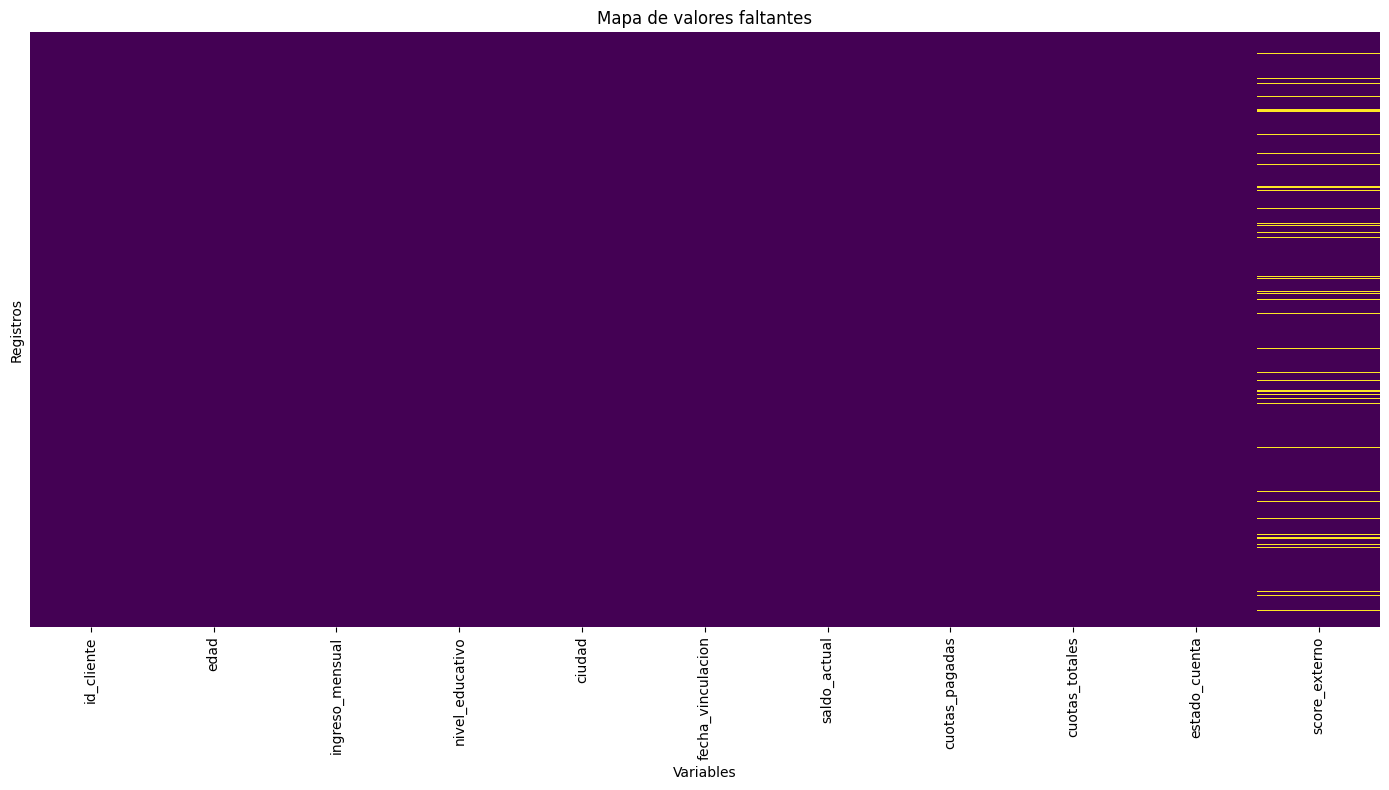

,cantidad_nulos,porcentaje_nulos
score_externo,1141,7.61
edad,0,0.00
id_cliente,0,0.00
ingreso_mensual,0,0.00
nivel_educativo,0,0.00
fecha_vinculacion,0,0.00
ciudad,0,0.00
saldo_actual,0,0.00
cuotas_pagadas,0,0.00
cuotas_totales,0,0.00


Filas con al menos un nulo: 1,141
Porcentaje de filas con nulos: 7.61%
Filas completas: 13,859
Archivo guardado: mapa_nulos.png


In [24]:
# Cantidad y porcentaje de nulos por columna
resumen_nulos = pd.DataFrame({
    "cantidad_nulos": df.isnull().sum(),
    "porcentaje_nulos": (df.isnull().mean() * 100).round(2)
}).sort_values("cantidad_nulos", ascending=False)

# Filas con al menos un valor nulo
filas_con_nulos = df.isnull().any(axis=1)
cantidad_filas_con_nulos = filas_con_nulos.sum()
porcentaje_filas_con_nulos = filas_con_nulos.mean() * 100

# Mapa de calor
plt.figure(figsize=(14, 8))

sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cbar=False,
    cmap="viridis"
)

plt.title("Mapa de valores faltantes")
plt.xlabel("Variables")
plt.ylabel("Registros")
plt.tight_layout()

plt.savefig(
    os.path.join(carpeta_salida, "mapa_nulos.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(resumen_nulos)

print(f"Filas con al menos un nulo: {cantidad_filas_con_nulos:,}")
print(f"Porcentaje de filas con nulos: {porcentaje_filas_con_nulos:.2f}%")
print(f"Filas completas: {(~filas_con_nulos).sum():,}")
print("Archivo guardado: mapa_nulos.png")

In [25]:
display(df[filas_con_nulos].head(20))

,id_cliente,edad,ingreso_mensual,nivel_educativo,ciudad,fecha_vinculacion,saldo_actual,cuotas_pagadas,cuotas_totales,estado_cuenta,score_externo
36,CLI-100036,32,0,Posgrado,CAL,2019-09-10,629040,13,18,Al día,NaN
38,CLI-100038,29,1817103,Secundaria,MANIZALES,2019-10-01,0,36,36,Cancelado,NaN
47,CLI-100047,63,5188948,Posgrado,SANTA MARTA,2015-03-28,0,24,24,Cancelado,NaN
52,CLI-100052,27,4514702,Técnico,"Bogotá, Colombia",2020-01-08,7541861,2,18,Moroso,NaN
57,CLI-100057,51,3242656,Técnico,IBAGUÉ,2017-09-14,2236043,6,12,Al día,NaN
63,CLI-100063,47,900000,Tecnólogo,CAL,2015-06-16,8341170,5,18,Moroso,NaN
66,CLI-100066,32,0,Secundaria,BUCARAMANGA,2023-08-23,2687425,1,12,Moroso,NaN
70,CLI-100070,34,2362663,Tecnólogo,CARTAGENA,2020-12-06,0,48,48,Cancelado,NaN
73,CLI-100073,57,0,Posgrado,Manizales,2023-09-06,5211882,6,18,Moroso,NaN
96,CLI-100096,3,0,Secundaria,Pereira,2018-01-11,26840511,3,48,Moroso,NaN


# PASO 7. Detección y análisis de duplicados

In [26]:
# Duplicados exactos
cantidad_duplicados_exactos = df.duplicated().sum()
duplicados_exactos = df[df.duplicated(keep=False)].sort_values(
    by=df.columns.tolist()
)

print(f"Duplicados exactos encontrados: {cantidad_duplicados_exactos}")
display(duplicados_exactos.head(20))

# IDs duplicados
if "id_cliente" in df.columns:
    cantidad_ids_duplicados = df["id_cliente"].duplicated().sum()

    ids_duplicados = df[
        df["id_cliente"].duplicated(keep=False)
    ].sort_values("id_cliente")

    print(f"IDs de cliente duplicados: {cantidad_ids_duplicados}")
    display(ids_duplicados.head(30))
else:
    print("No existe la columna id_cliente.")

# Resumen para documentar
resumen_duplicados = pd.DataFrame({
    "tipo": ["Duplicados exactos", "IDs duplicados"],
    "cantidad": [
        cantidad_duplicados_exactos,
        cantidad_ids_duplicados if "id_cliente" in df.columns else np.nan
    ]
})

display(resumen_duplicados)

Duplicados exactos encontrados: 0


,id_cliente,edad,ingreso_mensual,nivel_educativo,ciudad,fecha_vinculacion,saldo_actual,cuotas_pagadas,cuotas_totales,estado_cuenta,score_externo


IDs de cliente duplicados: 0


,id_cliente,edad,ingreso_mensual,nivel_educativo,ciudad,fecha_vinculacion,saldo_actual,cuotas_pagadas,cuotas_totales,estado_cuenta,score_externo


,tipo,cantidad
0,Duplicados exactos,0
1,IDs duplicados,0


# PASO 8. Verificación de tipos de dato y conversiones

In [27]:
import numpy as np
import pandas as pd

columnas_texto = df.select_dtypes(include=["object", "string"]).columns
resultados_tipos = []

# 1. Detectar columnas de fechas por el nombre
palabras_fecha = ["fecha", "date", "time"]

columnas_fecha = [
    columna for columna in columnas_texto
    if any(palabra in columna.lower() for palabra in palabras_fecha)
]

for columna in columnas_fecha:
    valores = df[columna]
    no_nulos = valores.notna()

    try:
        conversion = pd.to_datetime(
            valores,
            errors="coerce",
            format="mixed"
        )
    except TypeError:
        conversion = pd.to_datetime(
            valores,
            errors="coerce"
        )

    no_parseables = no_nulos & conversion.isna()
    total_evaluados = no_nulos.sum()
    exitosos = total_evaluados - no_parseables.sum()

    resultados_tipos.append({
        "columna": columna,
        "tipo_actual": str(df[columna].dtype),
        "tipo_sugerido": "datetime",
        "porcentaje_conversion_exitosa": (
            round(exitosos / total_evaluados * 100, 2)
            if total_evaluados > 0 else np.nan
        ),
        "valores_no_parseables": int(no_parseables.sum()),
        "ejemplos_problematicos": (
            df.loc[no_parseables, columna]
            .astype(str)
            .unique()[:5]
            .tolist()
        )
    })


# 2. Detectar columnas numéricas almacenadas como texto
for columna in columnas_texto:
    if columna in columnas_fecha:
        continue

    valores = df[columna]
    no_nulos = valores.notna()
    total_evaluados = no_nulos.sum()

    conversion = pd.to_numeric(
        valores.astype("string").str.strip(),
        errors="coerce"
    )

    exitosos = (conversion.notna() & no_nulos).sum()
    porcentaje_exito = (
        exitosos / total_evaluados * 100
        if total_evaluados > 0 else 0
    )

    if porcentaje_exito >= 90:
        no_parseables = no_nulos & conversion.isna()

        resultados_tipos.append({
            "columna": columna,
            "tipo_actual": str(df[columna].dtype),
            "tipo_sugerido": "numérico",
            "porcentaje_conversion_exitosa": round(porcentaje_exito, 2),
            "valores_no_parseables": int(no_parseables.sum()),
            "ejemplos_problematicos": (
                df.loc[no_parseables, columna]
                .astype(str)
                .unique()[:5]
                .tolist()
            )
        })


reporte_tipos = pd.DataFrame(resultados_tipos)

if reporte_tipos.empty:
    print("No se detectaron columnas con posibles tipos incorrectos.")
else:
    display(reporte_tipos)

reporte_tipos.to_csv(
    f"{carpeta_salida}/reporte_conversion_tipos.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivo guardado: reporte_conversion_tipos.csv")

,columna,tipo_actual,tipo_sugerido,porcentaje_conversion_exitosa,valores_no_parseables,ejemplos_problematicos
0,fecha_vinculacion,object,datetime,100.0,0,[]


Archivo guardado: reporte_conversion_tipos.csv


#PASO 9. Formulación de hipótesis analíticas iniciales

In [28]:
hipotesis = []

def agregar_hipotesis(id_, variables, hipotesis_, evidencia, relevancia, verificacion):
    hipotesis.append({
        "ID": id_,
        "variables": variables,
        "hipotesis": hipotesis_,
        "evidencia_EDA": evidencia,
        "relevancia_SOLARIS": relevancia,
        "como_verificar": verificacion
    })


# H1: carga de deuda e ingreso
ratio_deuda_ingreso = (
    df["saldo_actual"] /
    df["ingreso_mensual"].replace(0, np.nan)
)

r1 = ratio_deuda_ingreso.corr(
    df["score_externo"],
    method="spearman"
)

agregar_hipotesis(
    "H1",
    "saldo_actual, ingreso_mensual, score_externo",
    "Una mayor carga de deuda respecto al ingreso está asociada con un menor score externo.",
    f"Correlación Spearman entre deuda/ingreso y score externo: {r1:.3f}.",
    "La razón deuda/ingreso podría ser una característica útil para estimar el riesgo crediticio.",
    "Crear la variable deuda_ingreso, realizar un gráfico de dispersión y probarla en un modelo de riesgo."
)


# H2: avance en el pago
avance_pago = (
    df["cuotas_pagadas"] /
    df["cuotas_totales"].replace(0, np.nan)
)

r2 = avance_pago.corr(
    df["score_externo"],
    method="spearman"
)

agregar_hipotesis(
    "H2",
    "cuotas_pagadas, cuotas_totales, score_externo",
    "Los clientes con mayor proporción de cuotas pagadas presentan un mejor score externo.",
    f"Correlación Spearman entre avance de pago y score externo: {r2:.3f}.",
    "El porcentaje de avance puede representar el comportamiento histórico de pago del cliente.",
    "Comparar el avance de pago entre niveles de score y evaluar su importancia en modelos predictivos."
)


# H3: ingresos en cero con deuda activa
mascara_validos = (
    df["ingreso_mensual"].notna() &
    df["saldo_actual"].notna()
)

mascara_ingreso_cero = (
    (df["ingreso_mensual"] == 0) &
    (df["saldo_actual"] > 0) &
    mascara_validos
)

proporcion_ingreso_cero = (
    mascara_ingreso_cero.sum() / mascara_validos.sum()
)

agregar_hipotesis(
    "H3",
    "ingreso_mensual, saldo_actual",
    "Los ingresos iguales a cero en clientes con saldo activo pueden representar errores de captura o ingresos no reportados.",
    f"{proporcion_ingreso_cero:.2%} de los registros válidos tiene ingreso cero y saldo superior a cero.",
    "Tratar estos ceros como ingresos reales podría distorsionar indicadores como deuda/ingreso y el modelo de riesgo.",
    "Contrastar los registros con la fuente original y comparar su estado de cuenta y score con el resto de clientes."
)


# H4: edades atípicas
mascara_edad_invalida = (
    (df["edad"] < 18) |
    (df["edad"] > 100)
)

proporcion_edad_invalida = mascara_edad_invalida.mean()

agregar_hipotesis(
    "H4",
    "edad",
    "Las edades fuera del rango esperado corresponden principalmente a errores de calidad de datos.",
    f"{mascara_edad_invalida.sum()} registros ({proporcion_edad_invalida:.2%}) tienen edad menor a 18 o mayor a 100.",
    "Las edades incorrectas pueden generar relaciones falsas con el riesgo crediticio.",
    "Validar las edades con la fecha de nacimiento o la fuente original antes de imputar o eliminar."
)


# H5: diferencias del score según estado de cuenta
medianas_estado = (
    df.groupby("estado_cuenta")["score_externo"]
    .median()
    .dropna()
)

if len(medianas_estado) >= 2:
    diferencia_mediana = medianas_estado.max() - medianas_estado.min()

    agregar_hipotesis(
        "H5",
        "estado_cuenta, score_externo",
        "El score externo presenta diferencias entre los distintos estados de cuenta.",
        f"La diferencia entre la mayor y menor mediana del score por estado es {diferencia_mediana:.2f} puntos.",
        "El score externo podría ayudar a segmentar clientes y anticipar estados de mayor riesgo.",
        "Comparar las distribuciones mediante boxplots y aplicar una prueba de Kruskal-Wallis."
    )


hipotesis_iniciales = pd.DataFrame(hipotesis)

hipotesis_iniciales.to_csv(
    f"{carpeta_salida}/hipotesis_iniciales.csv",
    index=False,
    encoding="utf-8-sig"
)

display(hipotesis_iniciales)

print("Archivo guardado: hipotesis_iniciales.csv")

,ID,variables,hipotesis,evidencia_EDA,relevancia_SOLARIS,como_verificar
0,H1,"saldo_actual, ingreso_mensual, score_externo",Una mayor carga de deuda respecto al ingreso e...,Correlación Spearman entre deuda/ingreso y sco...,La razón deuda/ingreso podría ser una caracter...,"Crear la variable deuda_ingreso, realizar un g..."
1,H2,"cuotas_pagadas, cuotas_totales, score_externo",Los clientes con mayor proporción de cuotas pa...,Correlación Spearman entre avance de pago y sc...,El porcentaje de avance puede representar el c...,Comparar el avance de pago entre niveles de sc...
2,H3,"ingreso_mensual, saldo_actual",Los ingresos iguales a cero en clientes con sa...,31.00% de los registros válidos tiene ingreso ...,Tratar estos ceros como ingresos reales podría...,Contrastar los registros con la fuente origina...
3,H4,edad,Las edades fuera del rango esperado correspond...,847 registros (5.65%) tienen edad menor a 18 o...,Las edades incorrectas pueden generar relacion...,Validar las edades con la fecha de nacimiento ...
4,H5,"estado_cuenta, score_externo",El score externo presenta diferencias entre lo...,La diferencia entre la mayor y menor mediana d...,El score externo podría ayudar a segmentar cli...,Comparar las distribuciones mediante boxplots ...


Archivo guardado: hipotesis_iniciales.csv
